In [1]:
# Standard library imports
import sys
import os

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

# Setup path for src imports
notebooks_dir = os.path.dirname(os.path.abspath('__file__'))
root_dir = os.path.dirname(notebooks_dir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.data_processing import load_dataset, get_features_and_targets
from src.evaluation import learning_curve_analysis, diagnose_fit
from src.visualisation import plot_learning_curve


In [2]:
# Importing important libraries

print("All libraries loaded...")


All libraries loaded...


In [3]:
# Load dataset
df = load_dataset()
X_encoded, y_stress, y_deflection = get_features_and_targets(df)

print("X_encoded shape:", X_encoded.shape)


X_encoded shape: (81, 6)


In [4]:
# Learning curve configuration - model chosen -> GPR
gpr_model = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0, (1e-5, 1e7)) * RBF(length_scale=[1.0]*6, length_scale_bounds=(1e-2, 1e3)),
    alpha=1e-8, n_restarts_optimizer=15, random_state=42
)

train_sizes = np.linspace(0.2, 1.0, 8)

print("Learning curve configured for GP (5-fold CV, 8 training-size steps)")


Learning curve configured for GP (5-fold CV, 8 training-size steps)


# Stress Model Learning Curve


In [5]:
# Learning curve - Stress
res_s = learning_curve_analysis(gpr_model, X_encoded, y_stress, train_sizes=train_sizes)
sizes_s = res_s['sizes']
train_mean_s, train_std_s = res_s['train_mean'], res_s['train_std']
val_mean_s, val_std_s = res_s['val_mean'], res_s['val_std']

print("Training sizes:", sizes_s)
print("Train R2:", np.round(train_mean_s, 4))
print("Val R2:", np.round(val_mean_s, 4))


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again m

C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 24 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 26 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound

C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 23 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 25 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again m

...

C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 32 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again m

C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 22 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://sciki

C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 23 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Training sizes: [12 20 27 34 42 49 56 64]
Train R2: [1. 1. 1. 1. 1. 1. 1. 1.]
Val R2: [0.9779 1.     1.     1.     1.     1.     1.     1.    ]


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


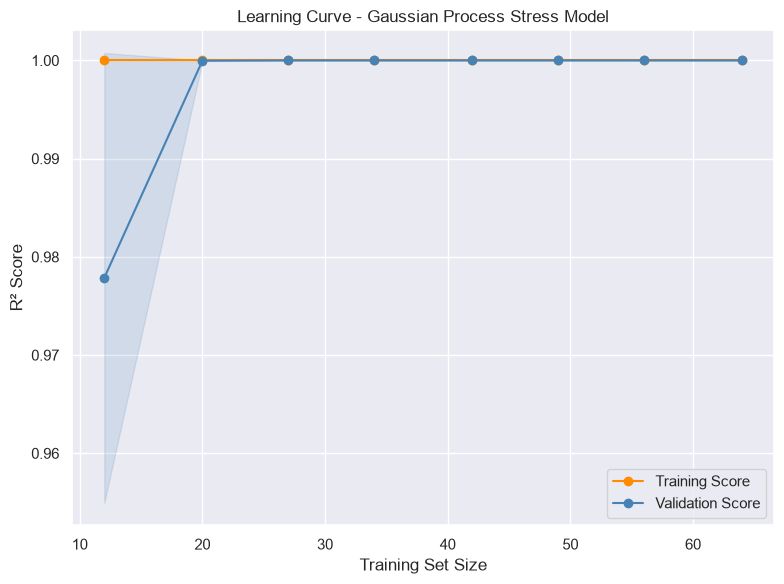

In [6]:
# Plot - Stress learning curve using src visualization
plot_learning_curve(
    sizes_s, train_mean_s, train_std_s, val_mean_s, val_std_s,
    title="Learning Curve - Gaussian Process Stress Model"
)
plt.show()


# Deformation Model Learning Curve


In [7]:
# Learning curve - Deflection
res_d = learning_curve_analysis(gpr_model, X_encoded, y_deflection, train_sizes=train_sizes)
sizes_d = res_d['sizes']
train_mean_d, train_std_d = res_d['train_mean'], res_d['train_std']
val_mean_d, val_std_d = res_d['val_mean'], res_d['val_std']

print("Training sizes:", sizes_d)
print("Train R2:", np.round(train_mean_d, 4))
print("Val R2:", np.round(val_mean_d, 4))


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 24 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 18 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again m

C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 21 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again m

C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 26 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


...

C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again m

C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 21 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 15 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  

Training sizes: [12 20 27 34 42 49 56 64]
Train R2: [1. 1. 1. 1. 1. 1. 1. 1.]
Val R2: [0.8924 0.9999 1.     1.     1.     1.     1.     1.    ]


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 24 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again m

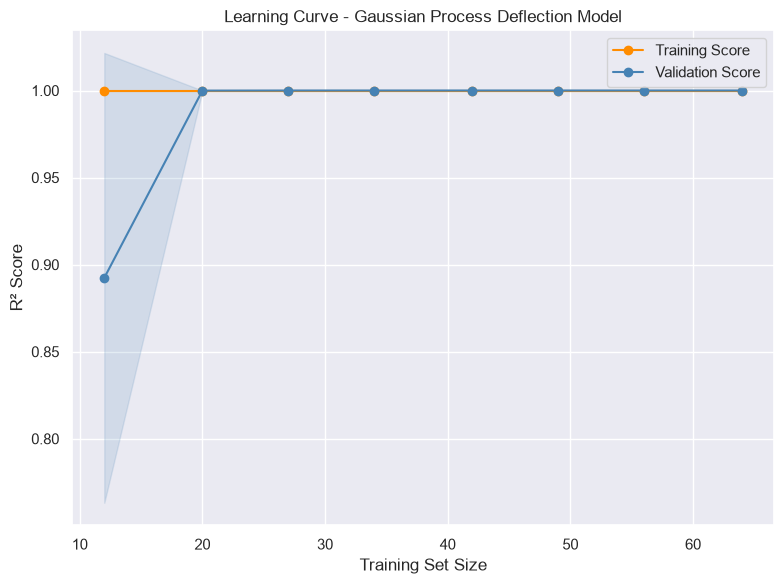

In [8]:
# Plot - Deflection learning curve using src visualization
plot_learning_curve(
    sizes_d, train_mean_d, train_std_d, val_mean_d, val_std_d,
    title="Learning Curve - Gaussian Process Deflection Model"
)
plt.show()


# Diagnosis Statement


In [9]:
# Model diagnosis table
diagnosis_df = pd.DataFrame([
    {"Model": "Stress", "Training Score": train_mean_s[-1], "Validation Score": val_mean_s[-1],
     "Diagnosis": diagnose_fit(train_mean_s[-1], val_mean_s[-1])},
    {"Model": "Deflection", "Training Score": train_mean_d[-1], "Validation Score": val_mean_d[-1],
     "Diagnosis": diagnose_fit(train_mean_d[-1], val_mean_d[-1])},
])
diagnosis_df


,Model,Training Score,Validation Score,Diagnosis
0,Stress,1.0,1.0,Well-fitted
1,Deflection,1.0,1.0,Well-fitted
